# Notebook 02: Exploratory Data Analysis (EDA)

Visualizing demographic, policy, vehicle, and incident distributions against fraud outcomes (`fraud_reported`).

In [1]:
import os
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

sns.set_theme(style="whitegrid")

data_path = '../data/raw/insurance_claims.csv' if os.path.exists('../data/raw/insurance_claims.csv') else 'data/raw/insurance_claims.csv'
df = pd.read_csv(data_path)
df['fraud_binary'] = df['fraud_reported'].map({'Y': 1, 'N': 0})


/var/folders/6w/q4_jg9xd4vv97jns6hh71l_w0000gn/T/ipykernel_78574/2122725455.py:3: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(data=df, x='fraud_reported', palette=['#2b5c8f', '#e05d06'])


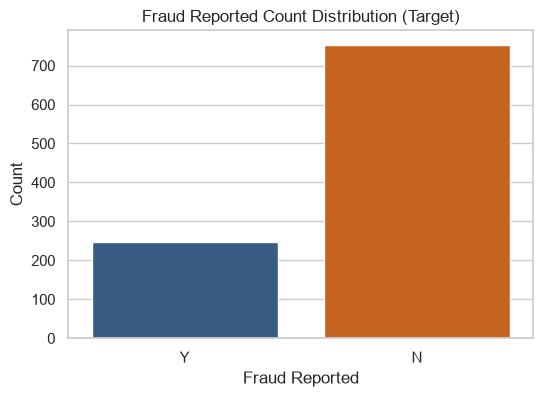

In [2]:
# 1. Target Distribution Plot
plt.figure(figsize=(6, 4))
sns.countplot(data=df, x='fraud_reported', palette=['#2b5c8f', '#e05d06'])
plt.title('Fraud Reported Count Distribution (Target)')
plt.ylabel('Count')
plt.xlabel('Fraud Reported')
plt.show()


/var/folders/6w/q4_jg9xd4vv97jns6hh71l_w0000gn/T/ipykernel_78574/1719987026.py:6: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(data=severity_df, x='incident_severity', y='fraud_rate', palette='Oranges_r')


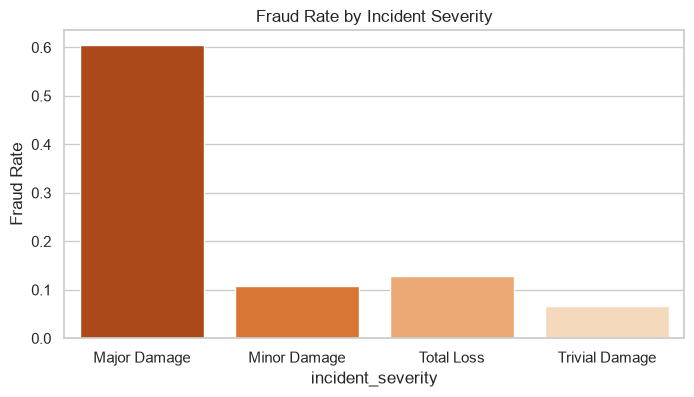

  incident_severity  total_claims  fraud_rate
0      Major Damage           276    0.605072
1      Minor Damage           354    0.107345
2        Total Loss           280    0.128571
3    Trivial Damage            90    0.066667


In [3]:
# 2. Fraud Rate by Incident Severity
plt.figure(figsize=(8, 4))
severity_df = df.groupby('incident_severity')['fraud_binary'].agg(['count', 'mean']).reset_index()
severity_df.columns = ['incident_severity', 'total_claims', 'fraud_rate']

sns.barplot(data=severity_df, x='incident_severity', y='fraud_rate', palette='Oranges_r')
plt.title('Fraud Rate by Incident Severity')
plt.ylabel('Fraud Rate')
plt.show()
print(severity_df)


/var/folders/6w/q4_jg9xd4vv97jns6hh71l_w0000gn/T/ipykernel_78574/2555721810.py:3: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=df, x='fraud_reported', y='total_claim_amount', palette=['#2b5c8f', '#e05d06'])


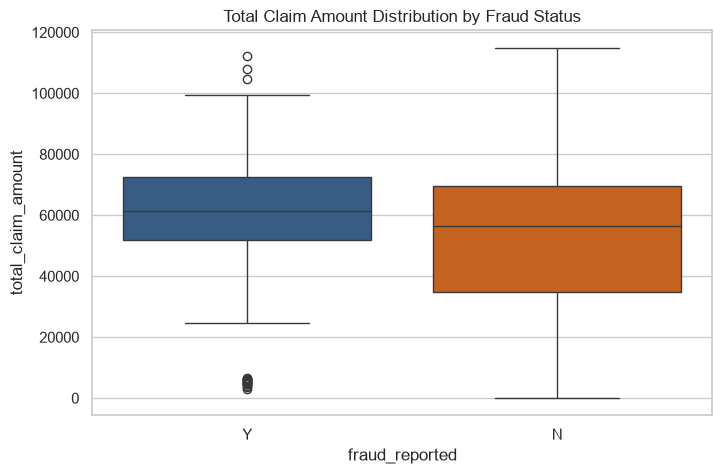

In [4]:
# 3. Numerical Features Distribution: Total Claim Amount by Fraud
plt.figure(figsize=(8, 5))
sns.boxplot(data=df, x='fraud_reported', y='total_claim_amount', palette=['#2b5c8f', '#e05d06'])
plt.title('Total Claim Amount Distribution by Fraud Status')
plt.show()


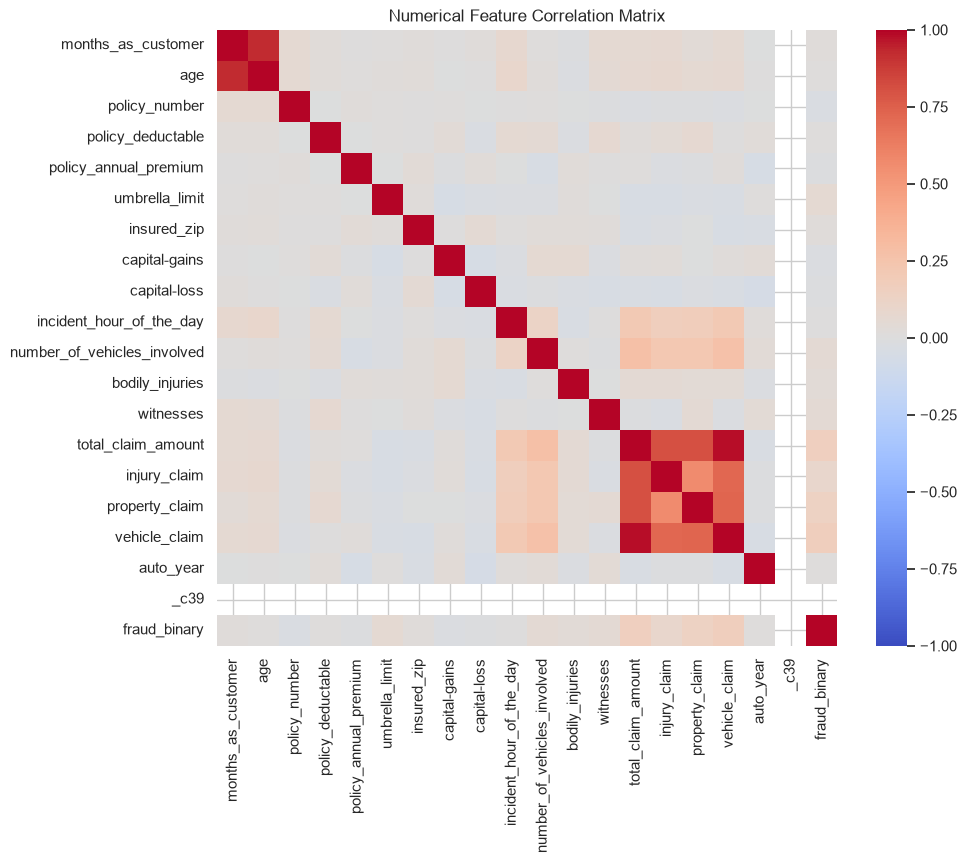

In [5]:
# 4. Correlation Matrix of Numerical Attributes
num_df = df.select_dtypes(include=[np.number])
plt.figure(figsize=(10, 8))
sns.heatmap(num_df.corr(), cmap='coolwarm', vmin=-1, vmax=1)
plt.title('Numerical Feature Correlation Matrix')
plt.show()
